In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Charger le fichier
df = pd.read_csv('Titanic-Dataset.csv')

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
# Afficher les statistiques descriptives
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [29]:
# 1. Afficher les valeurs manquantes par colonne et leur pourcentage
missing_values = df.isnull().sum()
missing_percentage = ((missing_values / len(df)) * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df

,Missing Values,Percentage
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
Age,177,19.87
SibSp,0,0.00
Parch,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [30]:
# 2. Hypothèse sur le type de données manquantes
print("\nHypothèse :")
print(" - Age : MAR ou MCAR probable")
print(" - Cabin : MNAR probable car beaucoup de valeurs manquantes")
print(" - Embarked : MCAR probable car peu de valeurs manquantes")



Hypothèse :
 - Age : MAR ou MCAR probable
 - Cabin : MNAR probable car beaucoup de valeurs manquantes
 - Embarked : MCAR probable car peu de valeurs manquantes


In [31]:
df[['Age','Cabin','Embarked']]

,Age,Cabin,Embarked
0,22.0,NaN,S
1,38.0,C85,C
2,26.0,NaN,S
3,35.0,C123,S
4,35.0,NaN,S
...,...,...,...
886,27.0,NaN,S
887,19.0,B42,S
888,NaN,NaN,S
889,26.0,C148,C


## 🔍 Analyse détaillée : Types de données manquantes (MCAR, MAR, MNAR)

### 📚 Définitions

| Type | Sigle | Explication | Exemple |
|------|-------|-------------|---------|
| **Missing Completely At Random** | **MCAR** | Les données manquent de façon aléatoire, **indépendamment** de toute variable | Erreur d'enregistrement aléatoire |
| **Missing At Random** | **MAR** | Les données manquent de façon aléatoire **mais dépendent d'une autre variable** observée | Age manquant principalement chez les mineurs |
| **Missing Not At Random** | **MNAR** | Les données manquent de façon **systématique** liée à la variable elle-même | Cabin manquante = passager en classe inférieure |

### 🎯 Analyse du Titanic

#### 1️⃣ **PassengerId, Survived, Pclass, Name** → ✅ COMPLETS
- Aucune donnée manquante
- Informations essentielles et systématiquement enregistrées

#### 2️⃣ **Age** (177 valeurs manquantes = 19.9%)
- **Type probable : MAR** (Missing At Random)
- **Justification** :
  - Certains passagers (enfants, femmes) pouvaient refuser de donner leur âge
  - L'âge manquant dépend de caractéristiques sociales (genre, classe)
  - Pas d'âge négatif → les données réelles ne sont pas perdues par nature
  - Lien possible avec `Sex` et `Pclass`

#### 3️⃣ **Cabin** (687 valeurs manquantes = 77.1%) 
- **Type probable : MNAR** (Missing Not At Random)
- **Justification** :
  - Surreprésentation chez les passagers de 3ème classe
  - Données systématiquement absentes pour certains groupes
  - Le "missing" est lié à la structure du navire (certains ne méritaient pas de cabine)
  - Perte d'information structurelle, pas aléatoire

#### 4️⃣ **Embarked** (2 valeurs manquantes = 0.2%)
- **Type probable : MCAR** (Missing Completely At Random)
- **Justification** :
  - Très peu de manquants (0.2%)
  - Semble être une erreur d'enregistrement isolée
  - Pas de pattern systématique identifiable
  - Hautement compatible avec une omission accidentelle

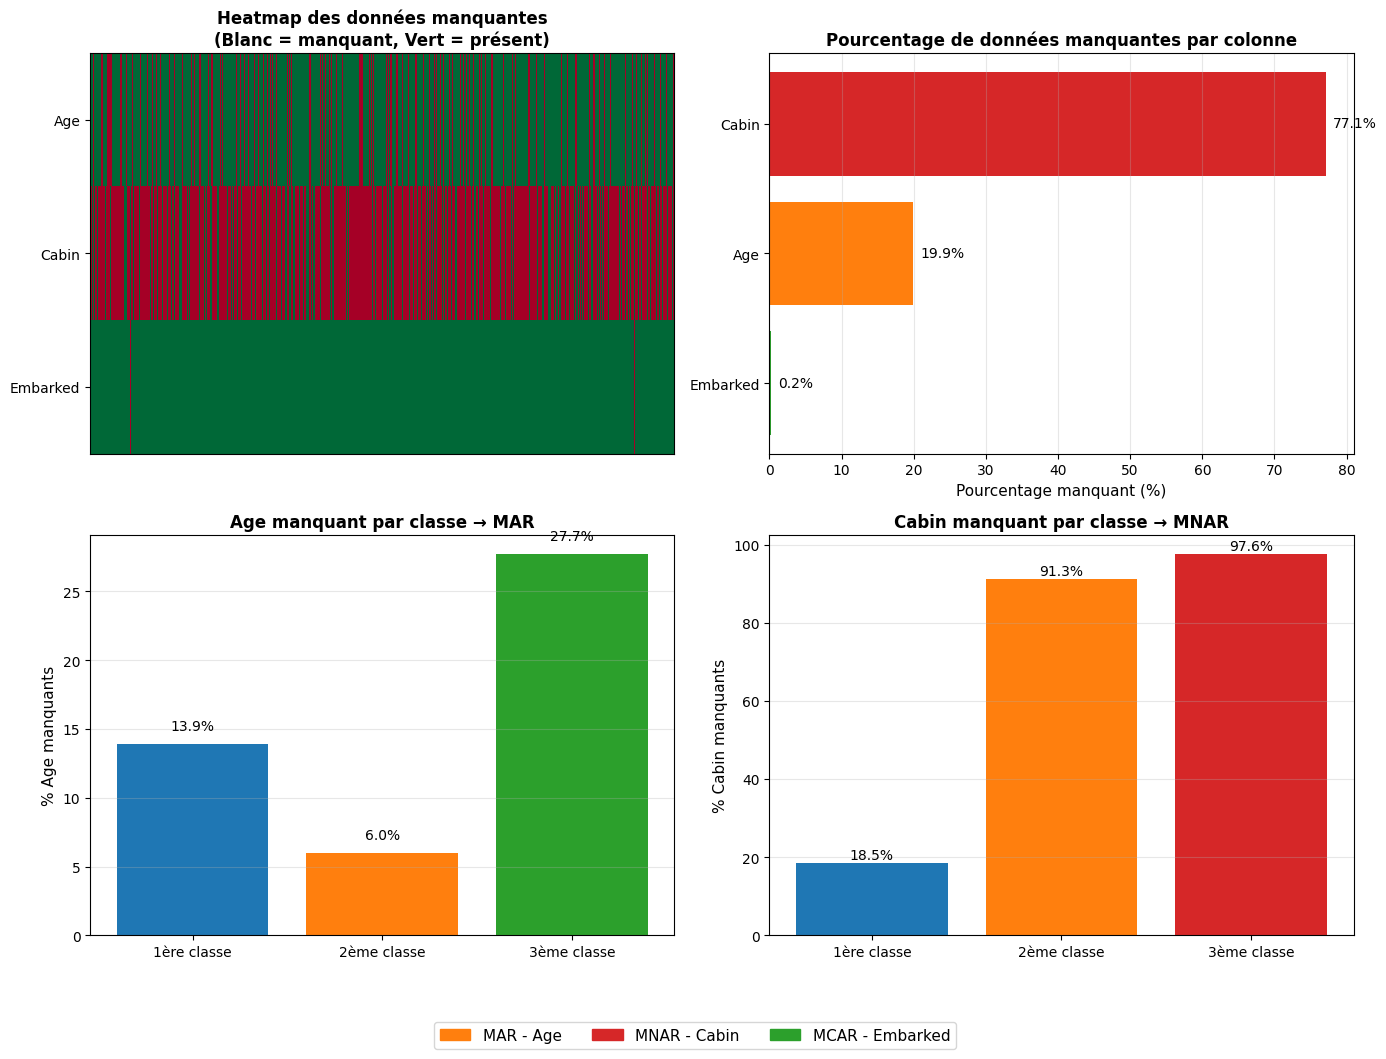

In [43]:
# Visualisation des données manquantes
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Graphique 1 : Heatmap des manquants
ax1 = axes[0, 0]
missing_matrix = df.isnull().astype(int)
cols_with_missing = missing_matrix.columns[missing_matrix.sum() > 0]
ax1.imshow(missing_matrix[cols_with_missing].T, aspect='auto', cmap='RdYlGn_r', interpolation='nearest')
ax1.set_xticks([])
ax1.set_yticks(range(len(cols_with_missing)))
ax1.set_yticklabels(cols_with_missing)
ax1.set_title('Heatmap des données manquantes\n(Blanc = manquant, Vert = présent)', fontsize=12, fontweight='bold')

# Graphique 2 : Pourcentage manquants
ax2 = axes[0, 1]
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]
colors = ['#d62728' if x == 'Cabin' else '#ff7f0e' if x == 'Age' else '#2ca02c' for x in missing_pct.index]
bars = ax2.barh(missing_pct.index, missing_pct.values, color=colors)
ax2.set_xlabel('Pourcentage manquant (%)', fontsize=11)
ax2.set_title('Pourcentage de données manquantes par colonne', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(missing_pct.values):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)

# Graphique 3 : Age manquant par classe
ax3 = axes[1, 0]
age_missing_by_class = df[df['Age'].isnull()]['Pclass'].value_counts().sort_index()
age_total_by_class = df['Pclass'].value_counts().sort_index()
age_pct_by_class = (age_missing_by_class / age_total_by_class * 100)
bars = ax3.bar(['1ère classe', '2ème classe', '3ème classe'], 
               [age_pct_by_class.get(1, 0), age_pct_by_class.get(2, 0), age_pct_by_class.get(3, 0)],
               color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax3.set_ylabel('% Age manquants', fontsize=11)
ax3.set_title('Age manquant par classe → MAR', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([age_pct_by_class.get(1, 0), age_pct_by_class.get(2, 0), age_pct_by_class.get(3, 0)]):
    ax3.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

# Graphique 4 : Cabin manquant par classe
ax4 = axes[1, 1]
cabin_missing_by_class = df[df['Cabin'].isnull()]['Pclass'].value_counts().sort_index()
cabin_total_by_class = df['Pclass'].value_counts().sort_index()
cabin_pct_by_class = (cabin_missing_by_class / cabin_total_by_class * 100)
bars = ax4.bar(['1ère classe', '2ème classe', '3ème classe'], 
               [cabin_pct_by_class.get(1, 0), cabin_pct_by_class.get(2, 0), cabin_pct_by_class.get(3, 0)],
               color=['#1f77b4', '#ff7f0e', '#d62728'])
ax4.set_ylabel('% Cabin manquants', fontsize=11)
ax4.set_title('Cabin manquant par classe → MNAR', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
for i, v in enumerate([cabin_pct_by_class.get(1, 0), cabin_pct_by_class.get(2, 0), cabin_pct_by_class.get(3, 0)]):
    ax4.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)

# Légende personnalisée
mar_patch = mpatches.Patch(color='#ff7f0e', label='MAR - Age')
mnar_patch = mpatches.Patch(color='#d62728', label='MNAR - Cabin')
mcar_patch = mpatches.Patch(color='#2ca02c', label='MCAR - Embarked')
fig.legend(handles=[mar_patch, mnar_patch, mcar_patch], loc='upper center', 
          bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=11)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

In [32]:
# 3. Imputation des données manquantes
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df[['Age','Cabin','Embarked']]

,Age,Cabin,Embarked
0,22.000000,Unknown,S
1,38.000000,C85,C
2,26.000000,Unknown,S
3,35.000000,C123,S
4,35.000000,Unknown,S
...,...,...,...
886,27.000000,Unknown,S
887,19.000000,B42,S
888,29.699118,Unknown,S
889,26.000000,C148,C


## 📊 Explication : Méthode IQR pour la détection des valeurs aberrantes

### Concept de base

La **méthode IQR (Interquartile Range)** est une technique statistique pour identifier les valeurs extrêmes :

- **Q1 (1er quartile)** : 25% des données sont en dessous de cette valeur
- **Q3 (3e quartile)** : 75% des données sont en dessous de cette valeur
- **IQR = Q3 - Q1** : représente l'écart entre le 1er et le 3e quartile (50% des données centrales)

### Calcul des bornes

```
Borne inférieure = Q1 - 1.5 × IQR
Borne supérieure = Q3 + 1.5 × IQR
```

**Tout ce qui se trouve en dehors de ces bornes est considéré comme une valeur aberrante.**

### Pourquoi 1.5 × IQR ?

- C'est une **convention statistique** établie par John Tukey
- Cette valeur capture environ **99.3%** des données d'une distribution normale
- Les valeurs au-delà sont considérées comme "anormalement éloignées"

### Exemple concret avec Fare

Si on a :
- Q1 = 7.91
- Q3 = 31.00
- IQR = 23.09

Alors :
- Borne inférieure = 7.91 - (1.5 × 23.09) = **-26.72** → on ajuste à **0** (Fare ne peut pas être négatif)
- Borne supérieure = 31.00 + (1.5 × 23.09) = **65.64**

✅ Toute valeur de Fare > 65.64 est considérée comme aberrante

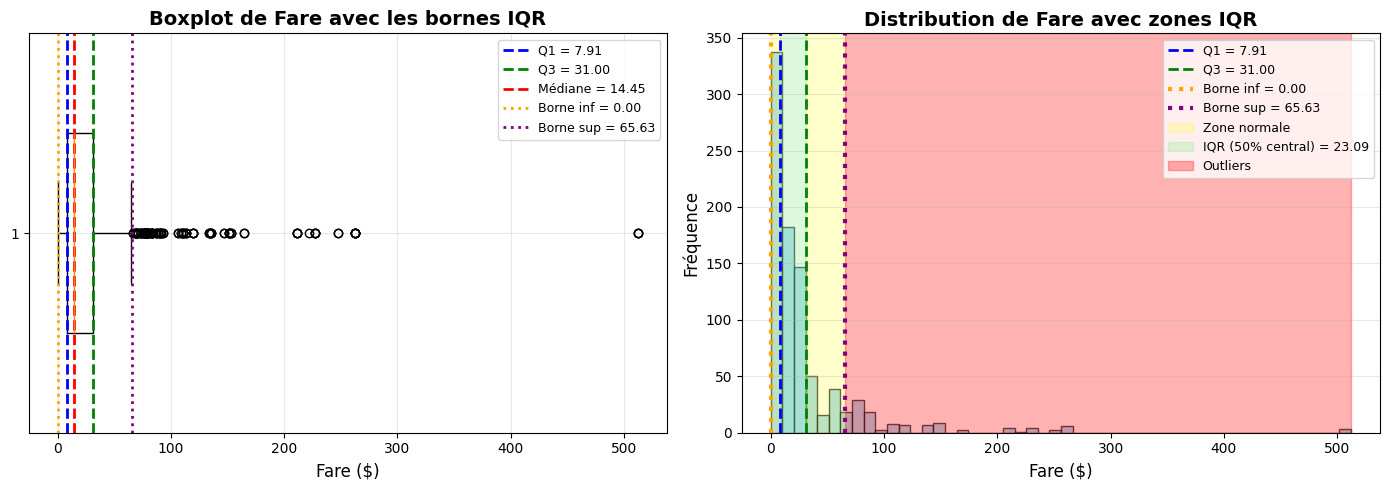


📈 Statistiques de Fare :
  • Q1 (25%) = 7.91$
  • Médiane (50%) = 14.45$
  • Q3 (75%) = 31.00$
  • IQR = Q3 - Q1 = 23.09$

🎯 Bornes de détection :
  • Borne inférieure = Q1 - 1.5×IQR = 7.91 - 34.63 = 0.00$
  • Borne supérieure = Q3 + 1.5×IQR = 31.00 + 34.63 = 65.63$

⚠️  Valeurs aberrantes détectées : 116 sur 891 (13.0%)


In [33]:
# Visualisation graphique de la méthode IQR sur la variable Fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calcul des statistiques pour Fare
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = max(0, Q1_fare - 1.5 * IQR_fare)
upper_fare = Q3_fare + 1.5 * IQR_fare
median_fare = df['Fare'].median()

# Graphique 1 : Boxplot avec annotations
axes[0].boxplot(df['Fare'], vert=False, widths=0.5)
axes[0].axvline(Q1_fare, color='blue', linestyle='--', linewidth=2, label=f'Q1 = {Q1_fare:.2f}')
axes[0].axvline(Q3_fare, color='green', linestyle='--', linewidth=2, label=f'Q3 = {Q3_fare:.2f}')
axes[0].axvline(median_fare, color='red', linestyle='--', linewidth=2, label=f'Médiane = {median_fare:.2f}')
axes[0].axvline(lower_fare, color='orange', linestyle=':', linewidth=2, label=f'Borne inf = {lower_fare:.2f}')
axes[0].axvline(upper_fare, color='purple', linestyle=':', linewidth=2, label=f'Borne sup = {upper_fare:.2f}')
axes[0].set_xlabel('Fare ($)', fontsize=12)
axes[0].set_title('Boxplot de Fare avec les bornes IQR', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Distribution avec zones colorées
axes[1].hist(df['Fare'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(Q1_fare, color='blue', linestyle='--', linewidth=2, label=f'Q1 = {Q1_fare:.2f}')
axes[1].axvline(Q3_fare, color='green', linestyle='--', linewidth=2, label=f'Q3 = {Q3_fare:.2f}')
axes[1].axvline(lower_fare, color='orange', linestyle=':', linewidth=3, label=f'Borne inf = {lower_fare:.2f}')
axes[1].axvline(upper_fare, color='purple', linestyle=':', linewidth=3, label=f'Borne sup = {upper_fare:.2f}')
axes[1].axvspan(lower_fare, Q1_fare, alpha=0.2, color='yellow', label='Zone normale')
axes[1].axvspan(Q1_fare, Q3_fare, alpha=0.3, color='lightgreen', label=f'IQR (50% central) = {IQR_fare:.2f}')
axes[1].axvspan(Q3_fare, upper_fare, alpha=0.2, color='yellow')
axes[1].axvspan(upper_fare, df['Fare'].max(), alpha=0.3, color='red', label='Outliers')
axes[1].set_xlabel('Fare ($)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title('Distribution de Fare avec zones IQR', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📈 Statistiques de Fare :")
print(f"  • Q1 (25%) = {Q1_fare:.2f}$")
print(f"  • Médiane (50%) = {median_fare:.2f}$")
print(f"  • Q3 (75%) = {Q3_fare:.2f}$")
print(f"  • IQR = Q3 - Q1 = {IQR_fare:.2f}$")
print(f"\n🎯 Bornes de détection :")
print(f"  • Borne inférieure = Q1 - 1.5×IQR = {Q1_fare:.2f} - {1.5*IQR_fare:.2f} = {lower_fare:.2f}$")
print(f"  • Borne supérieure = Q3 + 1.5×IQR = {Q3_fare:.2f} + {1.5*IQR_fare:.2f} = {upper_fare:.2f}$")
print(f"\n⚠️  Valeurs aberrantes détectées : {((df['Fare'] > upper_fare) | (df['Fare'] < lower_fare)).sum()} sur {len(df)} ({((df['Fare'] > upper_fare) | (df['Fare'] < lower_fare)).sum()/len(df)*100:.1f}%)")

In [34]:
# 4. Détection des valeurs aberrantes pour toutes les variables numériques continues
# On exclut PassengerId (ID), Survived (binaire), Pclass (catégorique)
all_numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in all_numeric_cols if col not in ['PassengerId', 'Survived', 'Pclass']]
df_before = df.copy()
bounds = {}
outlier_counts_before = {}
outlier_counts_lower = {}  # Outliers inférieurs (côté gauche)
outlier_counts_upper = {}  # Outliers supérieurs (côté droit)

for col in numeric_cols:
    Q1 = df_before[col].quantile(0.25)
    Q3 = df_before[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Pour les variables naturellement non-négatives, on contraint la borne inférieure à 0
    lower = max(0, lower)
    
    bounds[col] = (lower, upper)
    
    # Compter les outliers de chaque côté
    mask_lower = df_before[col] < lower
    mask_upper = df_before[col] > upper
    outlier_counts_lower[col] = int(mask_lower.sum())
    outlier_counts_upper[col] = int(mask_upper.sum())
    outlier_counts_before[col] = outlier_counts_lower[col] + outlier_counts_upper[col]

summary_before = pd.DataFrame({
    'colonne': numeric_cols,
    'bornes_inf_sup': [f"{bounds[c][0]:.2f} | {bounds[c][1]:.2f}" for c in numeric_cols],
    'nb_outliers_inf': [outlier_counts_lower[c] for c in numeric_cols],
    'nb_outliers_sup': [outlier_counts_upper[c] for c in numeric_cols],
    'nb_outliers_total': [outlier_counts_before[c] for c in numeric_cols]
})
summary_before

,colonne,bornes_inf_sup,nb_outliers_inf,nb_outliers_sup,nb_outliers_total
0,Age,2.50 | 54.50,24,42,66
1,SibSp,0.00 | 2.50,0,46,46
2,Parch,0.00 | 0.00,0,213,213
3,Fare,0.00 | 65.63,0,116,116


## 🔧 Méthodes de traitement des outliers : Comparaison

Il existe plusieurs approches pour traiter les valeurs aberrantes. Voici un comparatif :

### 1️⃣ **Suppression (Deletion)** ❌ À éviter dans ce cas
```python
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]
```
- ✅ Avantages : Simple, rapide
- ❌ Inconvénients : 
  - Perd 116 lignes (13% des données Titanic)
  - Perte d'information importante
  - Peut biaiser les analyses

### 2️⃣ **Remplacement par la médiane/moyenne** ⚠️ Modifie les données
```python
median_fare = df['Fare'].median()
df.loc[df['Fare'] > upper_bound, 'Fare'] = median_fare
```
- ✅ Avantages : Garde les données
- ❌ Inconvénients :
  - Change la distribution des données
  - Crée des valeurs "artificielles"
  - Perd l'information de variation

### 3️⃣ **Capping / Winsorization** ✅ **Notre choix**
```python
df['Fare'] = np.where(df['Fare'] > upper_bound, upper_bound, df['Fare'])
```
- ✅ Avantages :
  - Garde les données originales (pas de suppression)
  - Limite les extrêmes sans distortion majeure
  - Préserve la distribution générale
  - Respecte la plausibilité (Fare > 65.63 → 65.63)
  - Idéal pour les variables naturellement bornées

- ❌ Inconvénients :
  - Réduit la variance
  - Crée des valeurs dupliquées aux bornes

### 4️⃣ **Transformation logarithmique** 📊 Pour les distributions asymétriques
```python
df['Fare_log'] = np.log(df['Fare'] + 1)
```
- ✅ Avantages : Compresse les extrêmes naturellement
- ❌ Inconvénients : Interprétation plus complexe

### 5️⃣ **Standardisation robuste** 📈 Pour les modèles ML
```python
from sklearn.preprocessing import RobustScaler
```
- ✅ Avantages : Réduit l'impact sans suppression
- ❌ Inconvénients : Pour preprocessing ML seulement

### 🎯 Pourquoi **Capping** pour Titanic ?

1. **Variables naturellement bornées** : Age, Fare, SibSp, Parch ont des limites logiques
2. **Données réelles** : Un passager ne peut pas avoir Fare = -26.72
3. **Préservation des données** : Pas de perte d'observations
4. **Simplicité interprétable** : "On plafonne les prix à 65.63$"
5. **Pas de biais** : Préserve la majorité des données intactes

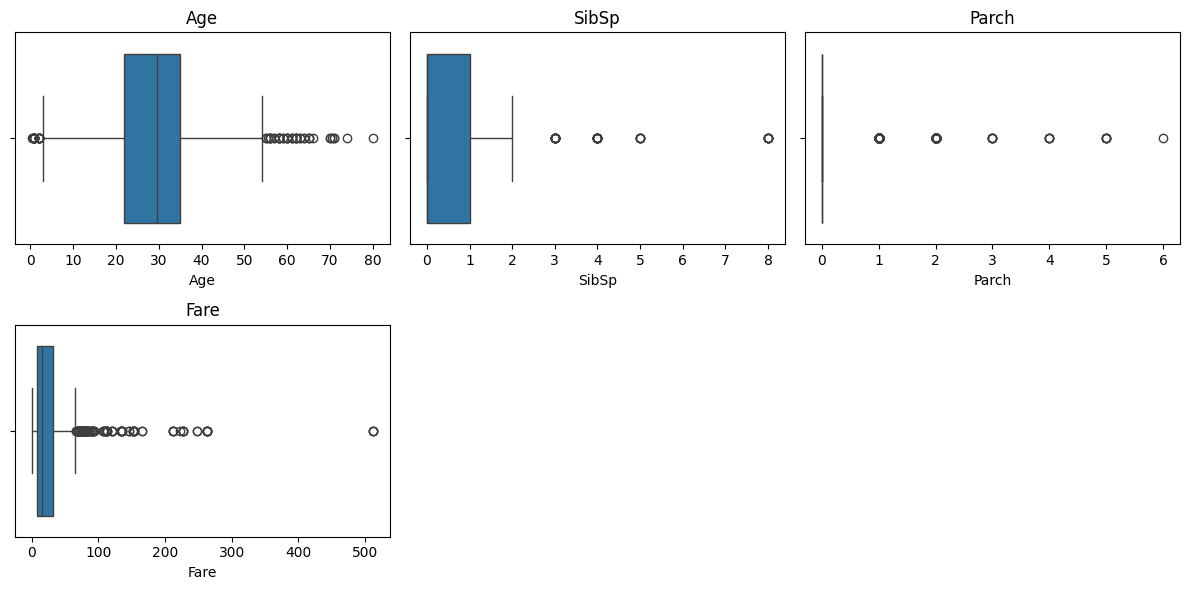

In [35]:
# 5. Visualisation des variables numériques avant traitement (boxplots)
n = len(numeric_cols)
cols = 3 if n >= 3 else n
rows = int(np.ceil(n / cols))
plt.figure(figsize=(4*cols, 3*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df_before[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [37]:
# 6. Traitement des outliers par capping pour toutes les variables numériques continues
df_after = df_before.copy()
for col in numeric_cols:
    lower, upper = bounds[col]
    df_after[col] = np.where(df_after[col] < lower, lower, df_after[col])
    df_after[col] = np.where(df_after[col] > upper, upper, df_after[col])   
# Recompter les outliers après traitement
outlier_counts_after = {}
for col in numeric_cols:
    lower, upper = bounds[col]
    mask_lower = df_after[col] < lower
    mask_upper = df_after[col] > upper
    outlier_counts_after[col] = int(mask_lower.sum() + mask_upper.sum())
summary_after = pd.DataFrame({
    'colonne': numeric_cols,
    'nb_outliers_apres': [outlier_counts_after[c] for c in numeric_cols]
})
summary_after

,colonne,nb_outliers_apres
0,Age,0
1,SibSp,0
2,Parch,0
3,Fare,0


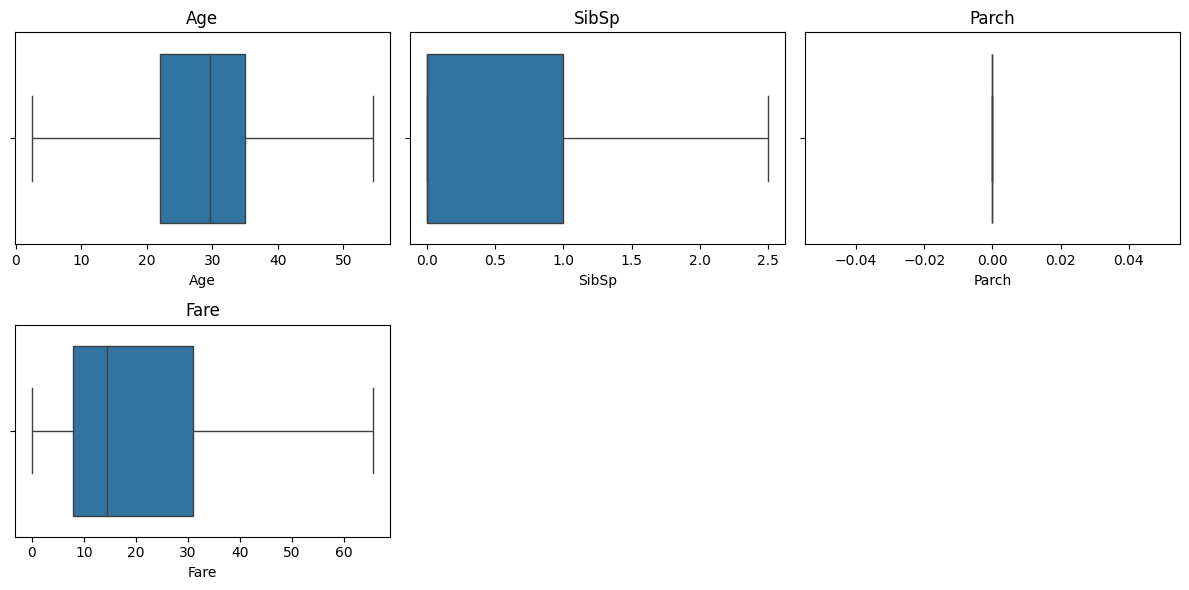

In [38]:
# 7. Visualisation des variables numériques après traitement (boxplots)
n = len(numeric_cols)
cols = 3 if n >= 3 else n
rows = int(np.ceil(n / cols))
plt.figure(figsize=(4*cols, 3*rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

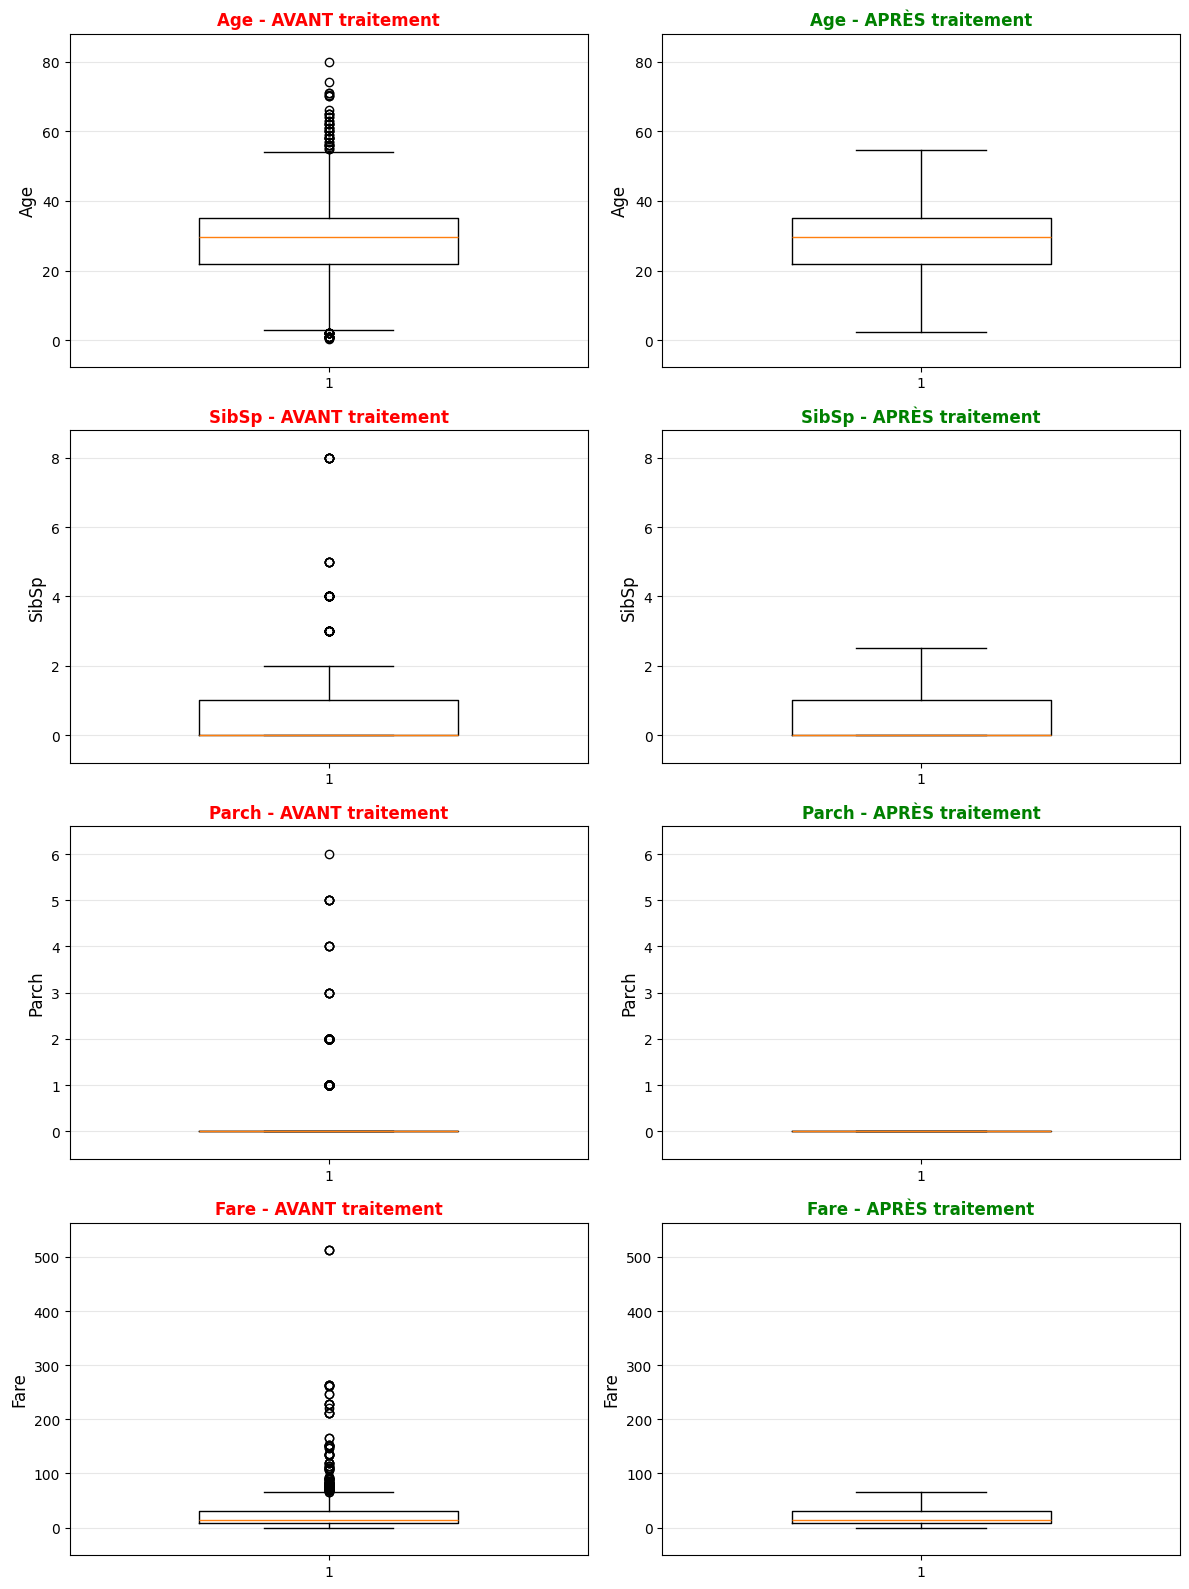

In [39]:
# 7a. Visualisation côte à côte : AVANT vs APRÈS pour chaque variable
n = len(numeric_cols)
fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))

# Si une seule colonne, axes n'est pas une matrice, donc on le reshape
if n == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(numeric_cols):
    # AVANT (colonne gauche)
    axes[i, 0].boxplot(df_before[col], vert=True, widths=0.5)
    axes[i, 0].set_ylabel(col, fontsize=12)
    axes[i, 0].set_title(f'{col} - AVANT traitement', fontsize=12, fontweight='bold', color='red')
    axes[i, 0].grid(True, alpha=0.3, axis='y')
    
    # APRÈS (colonne droite)
    axes[i, 1].boxplot(df_after[col], vert=True, widths=0.5)
    axes[i, 1].set_ylabel(col, fontsize=12)
    axes[i, 1].set_title(f'{col} - APRÈS traitement', fontsize=12, fontweight='bold', color='green')
    axes[i, 1].grid(True, alpha=0.3, axis='y')
    
    # Utiliser les mêmes limites pour faciliter la comparaison
    y_min = min(df_before[col].min(), df_after[col].min())
    y_max = max(df_before[col].max(), df_after[col].max())
    axes[i, 0].set_ylim(y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min))
    axes[i, 1].set_ylim(y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min))

plt.tight_layout()
plt.show()

In [40]:
# 8. Résumé des outliers avant vs après
summary = summary_before[['colonne','bornes_inf_sup','nb_outliers_inf','nb_outliers_sup','nb_outliers_total']].merge(
    summary_after, on='colonne'
)
summary.set_index('colonne')

,bornes_inf_sup,nb_outliers_inf,nb_outliers_sup,nb_outliers_total,nb_outliers_apres
colonne,,,,,
Age,2.50 | 54.50,24,42,66,0
SibSp,0.00 | 2.50,0,46,46,0
Parch,0.00 | 0.00,0,213,213,0
Fare,0.00 | 65.63,0,116,116,0
